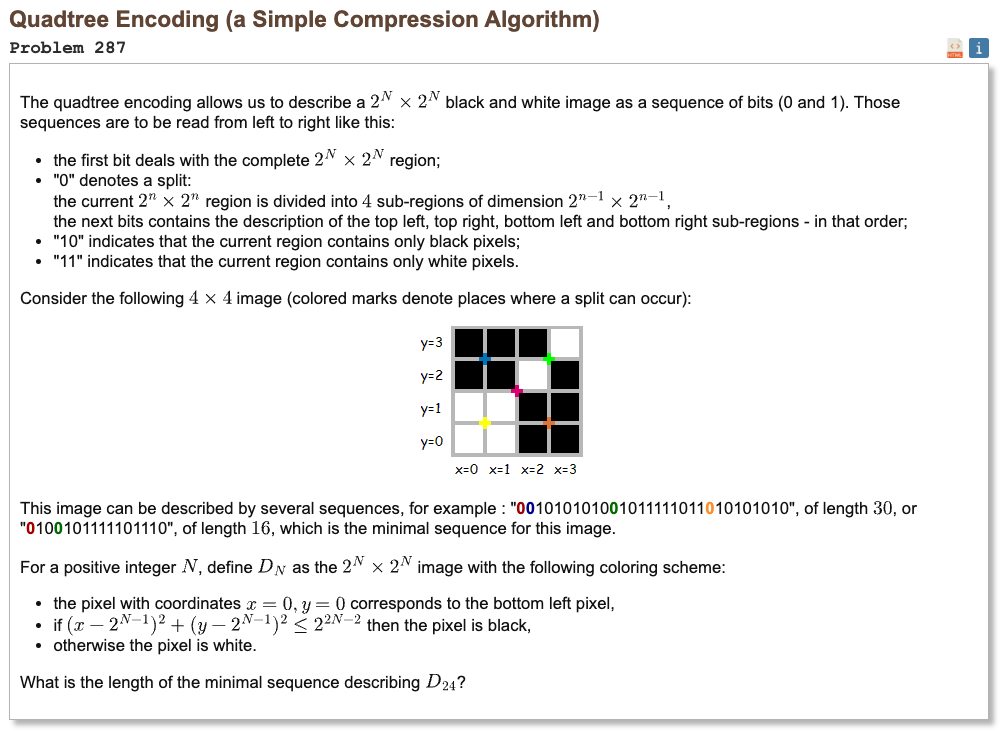

## Initial approach

* each square in the quadtree is either fully black, fully white, or mixed
* a mixed square costs 1 bit for the split plus the cost of its four children, while a uniform square costs 2 bits
* for this picture, the black area is a circle, square is fully black if its farthest corner is inside the circle
* a square is fully white if its nearest corner is outside the circle
* after the first split, every child sits on one side of the center lines, so each state can be described just by nonnegative distances from the circle center
* because the picture is symmetric, the same recursive function can be reused for many states, and caching makes it fast enough
* start from the four root quadrants, add their minimal lengths, and include 1 more bit for the first split
* use functools.lru_cache to avoid solving the same square many times

In [1]:
from functools import lru_cache

def minimal_length(n):
    r = 1 << (n - 1)
    r2 = r * r

    @lru_cache(None)
    def solve(x, y, size):
        if x > y:
            x, y = y, x

        if x * x + y * y > r2:
            return 2

        x2 = x + size - 1
        y2 = y + size - 1
        if x2 * x2 + y2 * y2 <= r2 or size == 1:
            return 2

        half = size // 2
        return (
            1
            + solve(x, y + half, half)
            + solve(x + half, y + half, half)
            + solve(x, y, half)
            + solve(x + half, y, half)
        )

    size = 1 << (n - 1)
    result = 1 + solve(0, 0, size) + 2 * solve(0, 1, size) + solve(1, 1, size)
    return result

In [2]:
%%time
result = minimal_length(24)
print("Result:", result)

Result: 313135496
CPU times: user 36.5 s, sys: 4.29 s, total: 40.8 s
Wall time: 43.5 s
